In [1]:
import pandas as pd
import sys
import os


project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("Project root:", project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocessing import preprocess
from src.preprocessing import preprocess
from src.models import train_arima, prepare_prophet, train_prophet, create_lstm

df = preprocess("../data/processed/covid_indonesia_processed.csv")
df.head()

Project root: C:\Users\user\Downloads\Data analyst\Covid_19_Project


,date,cases,deaths,recovered,daily_cases,daily_deaths,daily_recovered,daily_cases_lag1,daily_cases_lag7,daily_cases_lag14,...,daily_deaths_lag14,daily_recovered_lag1,daily_recovered_lag7,daily_recovered_lag14,daily_cases_roll7,daily_cases_roll14,case_growth_rate,log_daily_cases,log_daily_deaths,log_daily_recovered
0,2020-01-22,0,0,0,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,2020-01-23,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,2020-01-24,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3,2020-01-25,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,2020-01-26,0,0,0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


In [2]:
series = df["daily_cases"].dropna()
arima_model = train_arima(series)
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:            daily_cases   No. Observations:                 1143
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -10461.521
Date:                Mon, 11 May 2026   AIC                          20933.041
Time:                        16:34:32   BIC                          20958.244
Sample:                             0   HQIC                         20942.558
                               - 1143                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2102      0.038     -5.540      0.000      -0.285      -0.136
ar.L2          0.0619      0.037      1.663      0.096      -0.011       0.135
ma.L1          0.0944      0.036      2.643      0.0

16:34:35 - cmdstanpy - INFO - Chain [1] start processing
16:34:35 - cmdstanpy - INFO - Chain [1] done processing


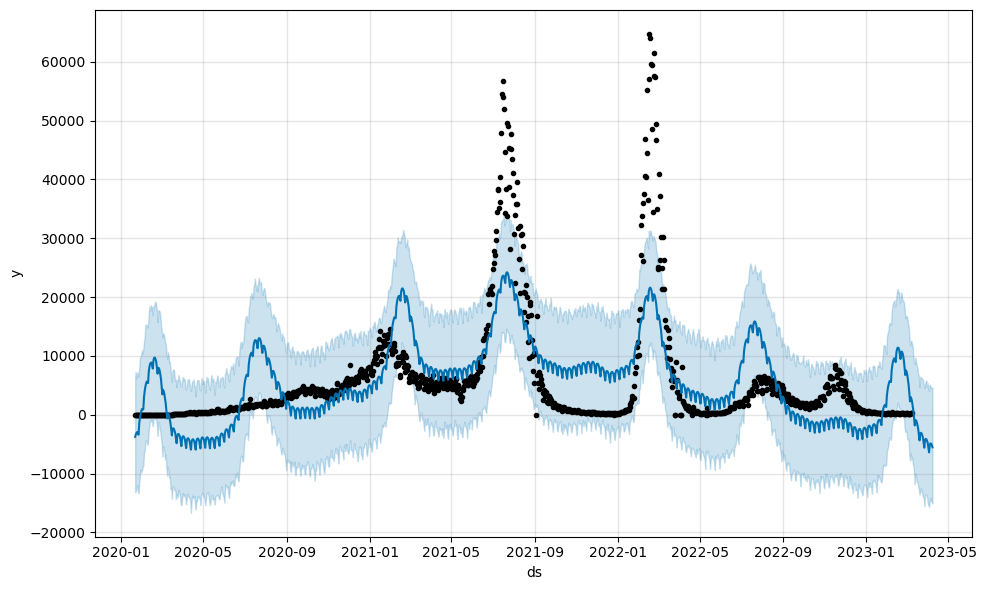

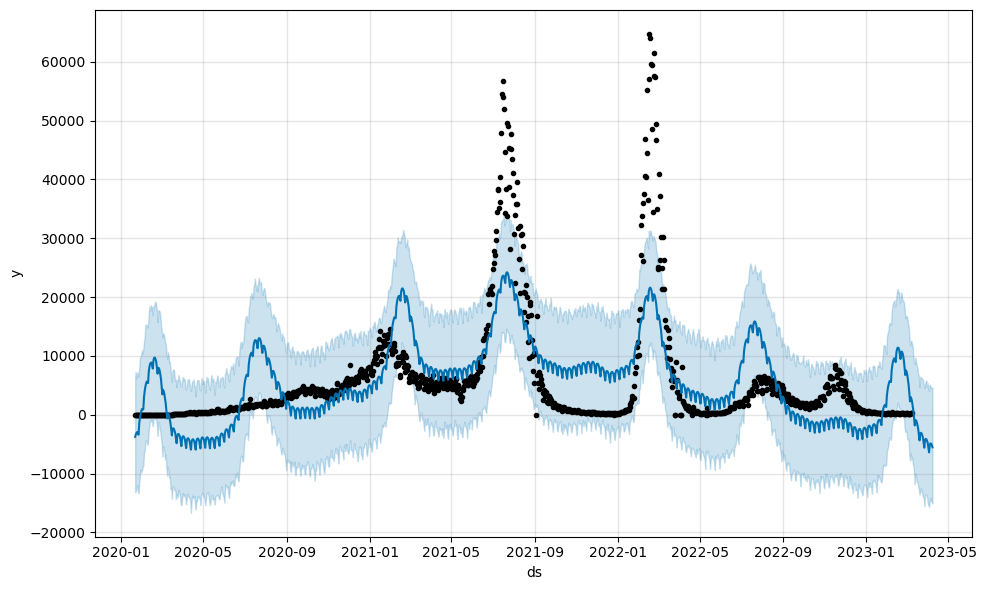

In [3]:
prophet_df = prepare_prophet(df)
prophet_model = train_prophet(prophet_df)
future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)
prophet_model.plot(forecast)

Epoch 1/20


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 125902520.0000
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 91547960.0000
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 48941192.0000
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20074542.0000
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10625413.0000
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7572304.0000
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7568482.0000
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8126743.5000
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6910089.0000
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6662874.0000
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6087014.0000
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6159382.5000
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6254065.5000
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5920402.5000
Epoch 

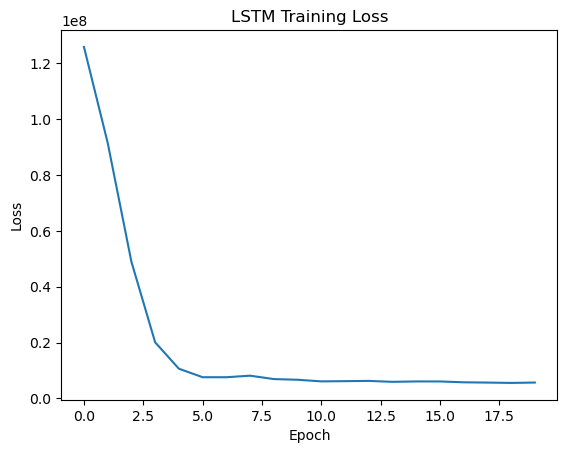

In [5]:
import numpy as np
from src.models import create_lstm

X = df[["daily_cases_lag1","daily_cases_lag7","daily_cases_lag14"]].dropna().values
y = df["daily_cases"].shift(-1).dropna().values

X = X[:len(y)]
y = y[:len(X)]

X = X.reshape((X.shape[0], 1, X.shape[1]))

lstm_model, history = create_lstm(X, y, input_shape=(X.shape[1], X.shape[2]))

print(history.history["loss"])

import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 📊 Model Training Summary

**ARIMA (2,1,2)**
  - Captured short-term autocorrelation in daily cases.
  - Significant AR and MA terms indicate past values strongly influence predictions.
  - Diagnostics reveal skewness and heavy kurtosis → data remains highly volatile.

**Prophet**
  - Fitted long-term trend and clear weekly seasonality.
  - Forecast captures recurring cycles (weekly & yearly) with uncertainty bands.
  - Highlights major peaks (2021 Delta, 2022 Omicron) and gradual decline after 2022.

**LSTM**
  - Neural network model trained on lag features.
  - Training loss decreased steadily across epochs → model successfully learned patterns.
  - Effective for capturing non-linear dynamics, though sensitive to hyperparameters.

---

### Key Takeaways
- **ARIMA** → strong baseline for short-term forecasting but limited with extreme spikes.  
- **Prophet** → excels at capturing seasonality and long-term trends, interpretable for stakeholders.  
- **LSTM** → flexible deep learning approach, effective for complex patterns but requires tuning and more data.  
- Combining insights from all three models provides a robust view: statistical rigor (ARIMA), interpretability (Prophet), and non-linear adaptability (LSTM).

---

## 📌 COVID-19 in Indonesia: Modeling Insights

- **Major Waves**: All models confirm two significant peaks — mid-2021 (Delta) and early 2022 (Omicron).  
- **Seasonality**: Prophet clearly shows weekly and yearly cycles, consistent with reporting effects and epidemic dynamics.  
- **Volatility**: ARIMA diagnostics highlight extreme skewness and kurtosis, reflecting unpredictable surges.  
- **Learning Patterns**: LSTM’s decreasing loss curve indicates lag features are informative for prediction.  
- **Long-Term Trend**: After 2022, models consistently show a decline in daily cases, suggesting a more controlled phase.  

**Overall:** Indonesia experienced two major COVID-19 waves with strong seasonality and extreme volatility. Statistical, interpretable, and deep learning models each provide complementary perspectives, together reinforcing the complex and dynamic nature of the pandemic.
